# Development pseudo-OOS: M0–M7

This extends the frozen [forecasting protocol](../docs/forecasts.md) with M6 elastic net and M7 shallow histogram boosting. Both use the unchanged M5b feature universe, per-origin chronological two-block tuning, and only labels matured by the forecast origin. All inputs are cut off at 2024-12-31 before feature construction. The existing [baseline](forecast_baselines.ipynb) and [linear-model](forecast_linear_models.ipynb) checkpoints remain separate; the 2025 confirmation sample is not evaluated.

## Development inputs and coverage

The SPX session calendar remains authoritative. Missing option metrics or exact-date market inputs cause model-specific abstention, not date compression or forward filling. The final five development labels are unavailable.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

project_root = Path.cwd().resolve()
if project_root.name == 'notebooks':
    project_root = project_root.parent
sys.path.insert(0, str(project_root))

from src.forecasting import (
    DEV_END, FULL_MODEL_LADDER, ML_MODELS, build_linear_development_dataset,
    forecast_ml_development, score_linear_development_forecasts,
    score_ml_development_forecasts,
)
from src.time_series import load_skew_metrics

metrics = load_skew_metrics(project_root / 'data/processed/spx_skew_metrics_2023_2025.csv')
metrics = metrics.loc[metrics['quote_date'] <= DEV_END].copy()
spx_prices = pd.read_csv(project_root / 'data/raw/spx_security_prices.csv')
spx_prices = spx_prices.loc[pd.to_datetime(spx_prices['date']) <= DEV_END].copy()
vix_prices = pd.read_csv(project_root / 'data/raw/VIX_security_prices.csv')
vix_prices = vix_prices.loc[pd.to_datetime(vix_prices['date']) <= DEV_END].copy()
development = build_linear_development_dataset(metrics, spx_prices, vix_prices)
display(pd.Series({
    'development sessions': len(development),
    'first session': development['quote_date'].min().date(),
    'last session': development['quote_date'].max().date(),
    'final five labels unavailable': development[
        ['y_skew_30_5d', 'y_skew_spread_5d']
    ].tail(5).isna().all().all(),
}))
targets = {
    '30D skew change': 'y_skew_30_5d',
    '30D–60D spread change': 'y_skew_spread_5d',
}
results = {
    name: forecast_ml_development(development, spx_prices, target)
    for name, target in targets.items()
}
scored = {name: score_ml_development_forecasts(results[name][0]) for name in targets}
coverage = pd.DataFrame([
    {'target': name, 'model': model, 'origins': len(results[name][0]),
     'realised_origins': int(results[name][0]['actual'].notna().sum()),
     'model_forecasts': int(results[name][0][model].notna().sum()),
     'individually_scorable': int(results[name][0][['actual', model]].notna().all(axis=1).sum()),
     'strict_common': len(scored[name][1])}
    for name in targets for model in FULL_MODEL_LADDER
])
display(coverage)

development sessions                    502
first session                    2023-01-03
last session                     2024-12-31
final five labels unavailable          True
dtype: object

,target,model,origins,realised_origins,model_forecasts,individually_scorable,strict_common
0,30D skew change,m0_persistence,250,245,250,245,238
1,30D skew change,m1_mean,250,245,250,245,238
2,30D skew change,m2_mean_reversion,250,245,250,245,238
3,30D skew change,m3_own_dynamics,250,245,250,245,238
4,30D skew change,m4_surface_state,250,245,243,238,238
5,30D skew change,m5a_realized_state,250,245,243,238,238
6,30D skew change,m5b_vix_state,250,245,243,238,238
7,30D skew change,m6_elastic_net,250,245,243,238,238
8,30D skew change,m7_hist_boosting,250,245,243,238,238
9,30D–60D spread change,m0_persistence,250,245,250,245,238


## Strict common-date comparison

The first table preserves the previous M0–M5b comparison on its own common dates. The second scores all nine models only where the realised target and every M0–M7 forecast exist. OOS R² uses M0 as benchmark; M3–M7 also use M2. M0 correlation and directional accuracy are undefined.

In [2]:
previous = {name: score_linear_development_forecasts(predictions)
            for name, (predictions, _) in results.items()}
print('Prior M0–M5b checkpoint, unchanged date set')
previous_summary = pd.concat({name: value[0] for name, value in previous.items()}, names=['target']).reset_index(level=0)
previous_summary[previous_summary.select_dtypes('number').columns] = previous_summary.select_dtypes('number').round(4)
display(previous_summary)
print('Strict M0–M7 common date set')
summary = pd.concat({name: value[0] for name, value in scored.items()}, names=['target']).reset_index(level=0)
summary[summary.select_dtypes('number').columns] = summary.select_dtypes('number').round(4)
display(summary)

Prior M0–M5b checkpoint, unchanged date set


,target,model,n_common,first_date,last_date,rmse,mae,r2_vs_persistence,r2_vs_mean_reversion,correlation,directional_accuracy
0,30D skew change,m0_persistence,238,2024-01-04,2024-12-23,0.1100,0.0830,0.0000,NaN,NaN,NaN
1,30D skew change,m1_mean,238,2024-01-04,2024-12-23,0.1105,0.0832,-0.0104,NaN,-0.5320,0.5546
2,30D skew change,m2_mean_reversion,238,2024-01-04,2024-12-23,0.0987,0.0752,0.1942,NaN,0.4585,0.6176
3,30D skew change,m3_own_dynamics,238,2024-01-04,2024-12-23,0.0998,0.0761,0.1771,-0.0213,0.4331,0.6303
4,30D skew change,m4_surface_state,238,2024-01-04,2024-12-23,0.0968,0.0763,0.2260,0.0394,0.4931,0.6387
5,30D skew change,m5a_realized_state,238,2024-01-04,2024-12-23,0.1000,0.0789,0.1738,-0.0253,0.4463,0.6050
6,30D skew change,m5b_vix_state,238,2024-01-04,2024-12-23,0.1010,0.0799,0.1563,-0.0471,0.4382,0.5882
0,30D–60D spread change,m0_persistence,238,2024-01-04,2024-12-23,0.0619,0.0465,0.0000,NaN,NaN,NaN
1,30D–60D spread change,m1_mean,238,2024-01-04,2024-12-23,0.0622,0.0467,-0.0096,NaN,-0.5365,0.4874
2,30D–60D spread change,m2_mean_reversion,238,2024-01-04,2024-12-23,0.0524,0.0404,0.2820,NaN,0.5494,0.6597


Strict M0–M7 common date set


,target,model,n_common,first_date,last_date,rmse,mae,r2_vs_persistence,r2_vs_mean_reversion,correlation,directional_accuracy
0,30D skew change,m0_persistence,238,2024-01-04,2024-12-23,0.1100,0.0830,0.0000,NaN,NaN,NaN
1,30D skew change,m1_mean,238,2024-01-04,2024-12-23,0.1105,0.0832,-0.0104,NaN,-0.5320,0.5546
2,30D skew change,m2_mean_reversion,238,2024-01-04,2024-12-23,0.0987,0.0752,0.1942,NaN,0.4585,0.6176
3,30D skew change,m3_own_dynamics,238,2024-01-04,2024-12-23,0.0998,0.0761,0.1771,-0.0213,0.4331,0.6303
4,30D skew change,m4_surface_state,238,2024-01-04,2024-12-23,0.0968,0.0763,0.2260,0.0394,0.4931,0.6387
5,30D skew change,m5a_realized_state,238,2024-01-04,2024-12-23,0.1000,0.0789,0.1738,-0.0253,0.4463,0.6050
6,30D skew change,m5b_vix_state,238,2024-01-04,2024-12-23,0.1010,0.0799,0.1563,-0.0471,0.4382,0.5882
7,30D skew change,m6_elastic_net,238,2024-01-04,2024-12-23,0.0968,0.0742,0.2256,0.0389,0.4911,0.6387
8,30D skew change,m7_hist_boosting,238,2024-01-04,2024-12-23,0.0964,0.0754,0.2321,0.0470,0.4941,0.6387
0,30D–60D spread change,m0_persistence,238,2024-01-04,2024-12-23,0.0619,0.0465,0.0000,NaN,NaN,NaN


## Cumulative squared-error gains

Left: M2–M7 versus M0. Right: M3–M7 versus M2. All curves for a target use the strict M0–M7 dates. A broad gain is more credible than one brief jump; these are descriptive plots, not iid significance tests.

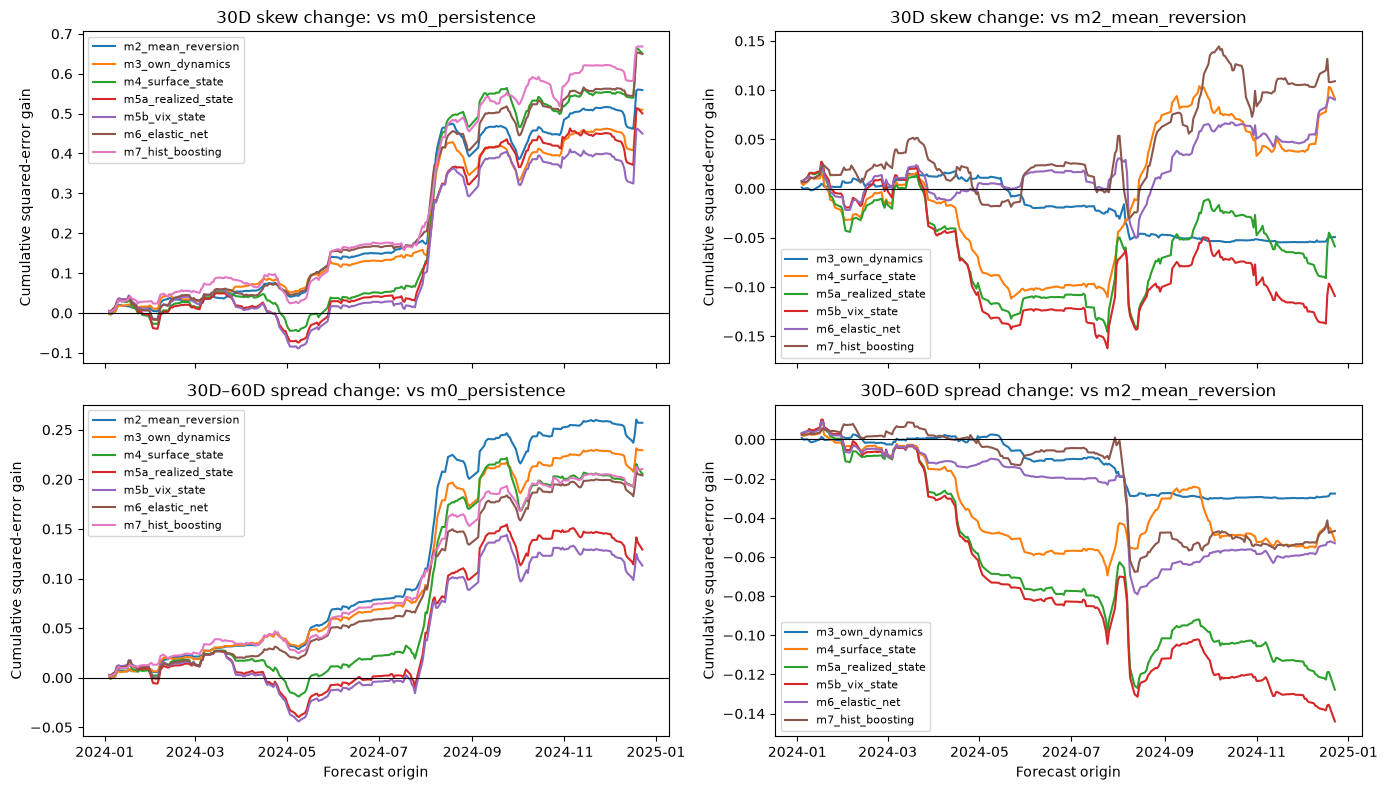

M6/M7 quarterly squared-error gain vs M2


quarter                                 2024Q1  2024Q2  2024Q3  2024Q4
target                model                                           
30D skew change       m6_elastic_net   -0.0033  0.0213  0.0476  0.0247
                      m7_hist_boosting  0.0295 -0.0026  0.0994 -0.0172
30D–60D spread change m6_elastic_net   -0.0119 -0.0081 -0.0395  0.0066
                      m7_hist_boosting  0.0021 -0.0067 -0.0485  0.0065

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex='col')
for row, (name, (_, common)) in enumerate(scored.items()):
    actual = common['actual']
    for column, (benchmark, models) in enumerate((
        ('m0_persistence', FULL_MODEL_LADDER[2:]),
        ('m2_mean_reversion', FULL_MODEL_LADDER[3:]),
    )):
        ax = axes[row, column]
        benchmark_error = (actual - common[benchmark]) ** 2
        for model in models:
            gain = benchmark_error - (actual - common[model]) ** 2
            ax.plot(common['quote_date'], gain.cumsum(), label=model)
        ax.axhline(0, color='black', linewidth=0.8)
        ax.set_title(f'{name}: vs {benchmark}')
        ax.set_ylabel('Cumulative squared-error gain')
        ax.legend(fontsize=8)
for ax in axes[-1]:
    ax.set_xlabel('Forecast origin')
fig.tight_layout()
plt.show()
quarterly = []
for name, (_, common) in scored.items():
    benchmark_error = (common['actual'] - common['m2_mean_reversion']) ** 2
    for model in ML_MODELS:
        gains = benchmark_error - (common['actual'] - common[model]) ** 2
        for quarter, value in gains.groupby(common['quote_date'].dt.to_period('Q')).sum().items():
            quarterly.append({'target': name, 'model': model, 'quarter': str(quarter), 'gain_vs_m2': value})
print('M6/M7 quarterly squared-error gain vs M2')
display(pd.DataFrame(quarterly).pivot(index=['target', 'model'], columns='quarter', values='gain_vs_m2').round(4))

## Five non-overlapping origin offsets

The original session_index % 5 splits the same strict common sample. No offset is selected or reindexed around missing observations.

In [4]:
offset_rows = []
for name, (_, common) in scored.items():
    for offset in range(5):
        subset = common.loc[common['session_index'].mod(5).eq(offset)]
        row = {'target': name, 'offset': offset, 'n': len(subset)}
        for model in ('m0_persistence', 'm2_mean_reversion', 'm4_surface_state', *ML_MODELS):
            row[model] = np.sqrt(np.mean((subset['actual'] - subset[model]) ** 2))
        offset_rows.append(row)
display(pd.DataFrame(offset_rows).round(4))

,target,offset,n,m0_persistence,m2_mean_reversion,m4_surface_state,m6_elastic_net,m7_hist_boosting
0,30D skew change,0,47,0.1117,0.1019,0.0978,0.0954,0.0986
1,30D skew change,1,48,0.1074,0.0981,0.0988,0.1022,0.0962
2,30D skew change,2,49,0.0968,0.0901,0.0886,0.0860,0.0853
3,30D skew change,3,46,0.1188,0.0977,0.0960,0.0966,0.0995
4,30D skew change,4,48,0.1146,0.1054,0.1023,0.1029,0.1018
5,30D–60D spread change,0,47,0.0574,0.0510,0.0503,0.0490,0.0512
6,30D–60D spread change,1,48,0.0674,0.0571,0.0601,0.0622,0.0564
7,30D–60D spread change,2,49,0.0605,0.0520,0.0544,0.0557,0.0550
8,30D–60D spread change,3,46,0.0596,0.0452,0.0499,0.0476,0.0524
9,30D–60D spread change,4,48,0.0638,0.0557,0.0566,0.0564,0.0560


## Inner-selection diagnostics

Candidate-level records retain pooled two-fold validation RMSE, training counts and selected settings per origin. Frequency and elastic-net sparsity are diagnostics only; the frozen grids are not changed in response.

In [5]:
diagnostics = pd.concat([value[1] for value in results.values()], ignore_index=True)
diagnostics_path = project_root / 'data/processed/forecast_ml_selection_dev_2023_2024.csv'
diagnostics.to_csv(diagnostics_path, index=False)
print(f'Per-origin candidate diagnostics saved to {diagnostics_path}')
display(diagnostics.groupby(['target', 'model', 'status']).size().rename('origins_or_candidates'))
selected = diagnostics.loc[diagnostics['selected'].eq(True)].copy()
print('Elastic-net selection frequency')
display(selected.loc[selected.model.eq('m6_elastic_net')].groupby(
    ['target', 'alpha', 'l1_ratio']
).size().rename('selected_origins'))
print('Boosting selection frequency')
display(selected.loc[selected.model.eq('m7_hist_boosting')].groupby(
    ['target', 'max_iter']
).size().rename('selected_origins'))
print('Elastic-net nonzero coefficient count (out of 14)')
display(selected.loc[selected.model.eq('m6_elastic_net')].groupby('target')[
    'nonzero_coefficients'].describe().round(2))

Per-origin candidate diagnostics saved to /Users/matthew/Desktop/PROJECT QUANT/Volatility-Forecasting-and-Options-Trading/data/processed/forecast_ml_selection_dev_2023_2024.csv


target            model             status        
y_skew_30_5d      m6_elastic_net    candidate         1215
                                    missing_origin       7
                                    selected           243
                  m7_hist_boosting  candidate          243
                                    missing_origin       7
                                    selected           243
y_skew_spread_5d  m6_elastic_net    candidate         1215
                                    missing_origin       7
                                    selected           243
                  m7_hist_boosting  candidate          243
                                    missing_origin       7
                                    selected           243
Name: origins_or_candidates, dtype: int64

Elastic-net selection frequency


target            alpha   l1_ratio
y_skew_30_5d      0.0001  0.25         21
                          0.75          8
                  0.0010  0.25         11
                          0.75         63
                  0.0100  0.25         39
                          0.75        101
y_skew_spread_5d  0.0001  0.25         26
                          0.75          9
                  0.0010  0.25         11
                          0.75         63
                  0.0100  0.25         61
                          0.75         73
Name: selected_origins, dtype: int64

Boosting selection frequency


target            max_iter
y_skew_30_5d      50.0        186
                  100.0        57
y_skew_spread_5d  50.0        185
                  100.0        58
Name: selected_origins, dtype: int64

Elastic-net nonzero coefficient count (out of 14)


,count,mean,std,min,25%,50%,75%,max
target,,,,,,,,
y_skew_30_5d,243.0,7.94,4.02,3.0,4.0,9.0,11.0,14.0
y_skew_spread_5d,243.0,7.33,3.97,2.0,3.0,8.0,11.0,14.0


## Interpretation

On the 238 strict common 2024 origins per target, M6 improves the 30D outright RMSE from 0.0987 (M2) to 0.0968 and MAE from 0.0752 to 0.0742. Its squared-error gain is positive in Q2–Q4 and on four of five non-overlapping offsets, so it **modestly satisfies** the frozen incremental-value rule; M6 is the provisional development choice for the outright target. M7 has a slightly lower RMSE (0.0964), but MAE is slightly worse than M2 and most of its net gain comes from Q3, so the simpler qualifying M6 is preferred. For the 30D–60D spread, both M6 and M7 have higher RMSE and MAE than M2 (RMSE 0.0524); M2 remains the development choice. These are descriptive development comparisons, not iid significance evidence or trading results. The 2025 locked confirmation remains untouched.